# 05. Final Visualizations

Reproducible script that trains all four models and saves comparison plots to 
`reports/figures/`. These plots are referenced in the main README.

**Generated artifacts:**
- `roc_curves_comparison.png` — ROC curves of all models
- `confusion_matrix_logreg.png` — Confusion matrix of the winning model
- `feature_importance_logreg.png` — Top features by absolute coefficient

In [1]:
import sys
sys.path.append('..')   # чтобы импорты из src/ работали из notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
import lightgbm as lgb

from src.preprocessing import (
    load_data,
    drop_redundant_features,
    split_features_target,
    split_train_test,
)

# Output directory
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
df = load_data()
df = drop_redundant_features(df)
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = split_train_test(X, y)

# Scaling for logreg
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (7903, 27), Test: (1976, 27)


In [3]:
# 1. Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest (default)
rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)
y_proba_rf_default = rf_default.predict_proba(X_test)[:, 1]

# 3. Random Forest (tuned)
rf_tuned = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=20,
    min_samples_split=50, random_state=42, n_jobs=-1,
)
rf_tuned.fit(X_train, y_train)
y_proba_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# 4. LightGBM (tuned)
# Need val split for early stopping
from sklearn.model_selection import train_test_split
X_train_fit, X_val, y_train_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42,
)

lgbm = LGBMClassifier(
    n_estimators=1000, learning_rate=0.01, num_leaves=15,
    min_child_samples=30, reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, verbosity=-1,
)
lgbm.fit(
    X_train_fit, y_train_fit,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print('All models trained.')

All models trained.


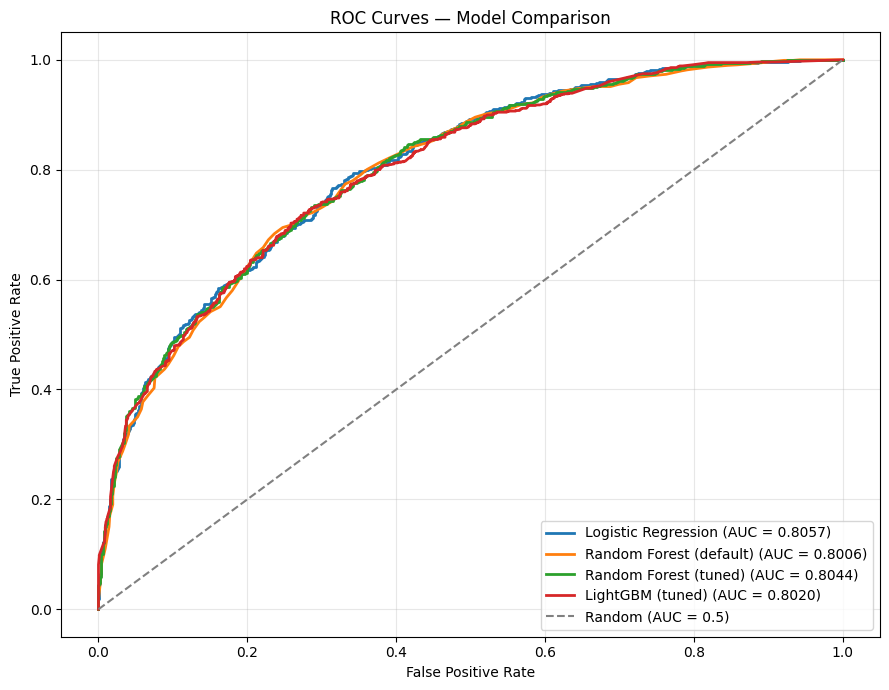

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))

models = {
    'Logistic Regression': y_proba_logreg,
    'Random Forest (default)': y_proba_rf_default,
    'Random Forest (tuned)': y_proba_rf_tuned,
    'LightGBM (tuned)': y_proba_lgbm,
}

for name, y_proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()

# Save
plt.savefig(FIGURES_DIR / 'roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

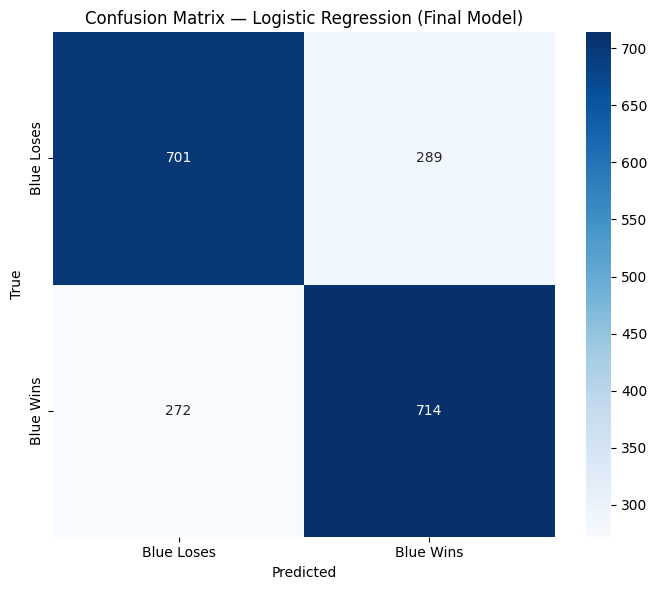

In [5]:
y_pred_logreg = logreg.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_logreg)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Blue Loses', 'Blue Wins'],
    yticklabels=['Blue Loses', 'Blue Wins'],
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Logistic Regression (Final Model)')
plt.tight_layout()

plt.savefig(FIGURES_DIR / 'confusion_matrix_logreg.png', dpi=150, bbox_inches='tight')
plt.show()

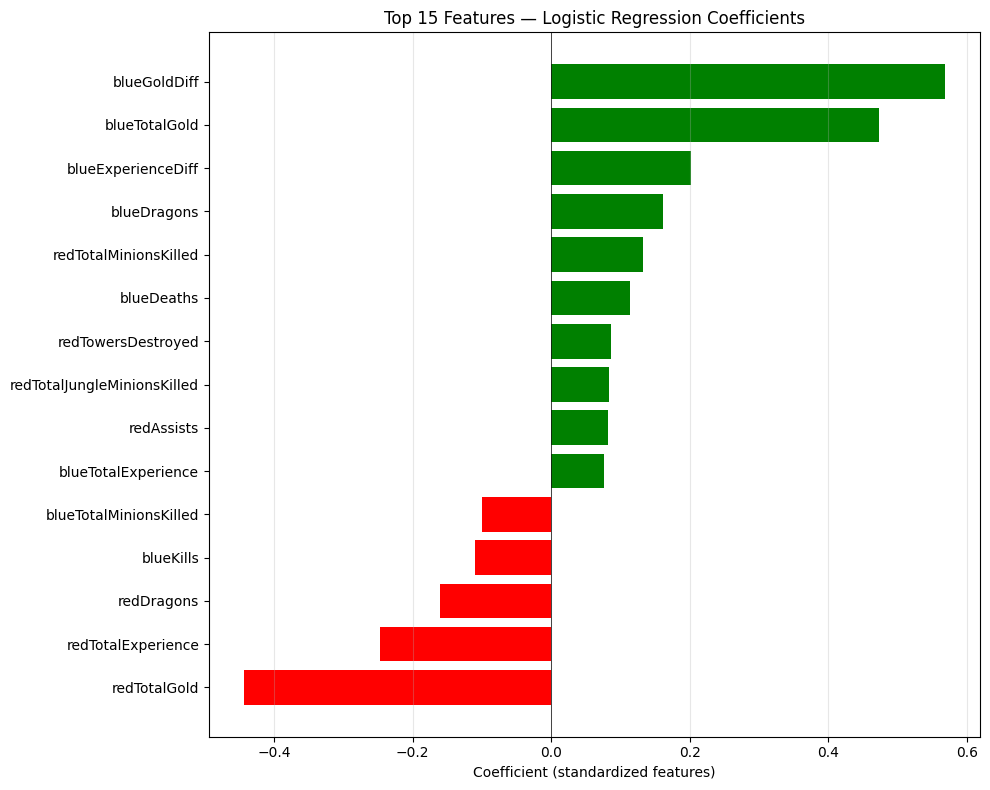

In [6]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': logreg.coef_[0],
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)
top_15 = coef_df.head(15).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in top_15['coefficient']]
ax.barh(top_15['feature'], top_15['coefficient'], color=colors)
ax.set_xlabel('Coefficient (standardized features)')
ax.set_title('Top 15 Features — Logistic Regression Coefficients')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()

plt.savefig(FIGURES_DIR / 'feature_importance_logreg.png', dpi=150, bbox_inches='tight')
plt.show()